<a href="https://colab.research.google.com/github/om-umrania/Weighted-Knowledge-Graph-Representation/blob/main/building_knowledge_graph_with_weights_with_sample_200.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import spacy
import numpy as np
import pandas as pd
import os
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Load sample data
candidate_sentences = pd.read_csv("./sample_data/wiki_sentences_v2.csv")



In [ ]:
# Entity Extraction Function
def get_entities(sent):
    ent1 = ""
    ent2 = ""
    prv_tok_dep = ""
    prv_tok_text = ""
    prefix = ""
    modifier = ""

    for tok in nlp(sent):
        if tok.dep_ != "punct":
            if tok.dep_ == "compound":
                prefix = tok.text
                if prv_tok_dep == "compound":
                    prefix = prv_tok_text + " " + tok.text
            if tok.dep_.endswith("mod"):
                modifier = tok.text
                if prv_tok_dep == "compound":
                    modifier = prv_tok_text + " " + tok.text
            if tok.dep_.find("subj") == True:
                ent1 = modifier + " " + prefix + " " + tok.text
                prefix = ""
                modifier = ""
            if tok.dep_.find("obj") == True:
                ent2 = modifier + " " + prefix + " " + tok.text
            prv_tok_dep = tok.dep_
            prv_tok_text = tok.text
    return [ent1.strip(), ent2.strip()]



In [ ]:
# Relation Extraction Function
def get_relation(sent):
    doc = nlp(sent)
    for tok in doc:
        if tok.dep_ == "ROOT":
            return tok.lemma_
    return ""

# Extract entity pairs and relationships
entity_pairs = [get_entities(i) for i in tqdm(candidate_sentences["sentence"])]
relations = [get_relation(i) for i in tqdm(candidate_sentences['sentence'])]

# Build DataFrame
source = [i[0] for i in entity_pairs]
target = [i[1] for i in entity_pairs]

kg_df = pd.DataFrame({'source': source, 'target': target, 'edge': relations})

# Compute edge weights
edge_weights = kg_df.groupby(['source', 'target', 'edge']).size().reset_index(name='weight')

# Create graph with edge weights
G = nx.from_pandas_edgelist(edge_weights, "source", "target", edge_attr=["edge", "weight"], create_using=nx.MultiDiGraph())



100%|██████████| 4318/4318 [00:38<00:00, 112.79it/s]


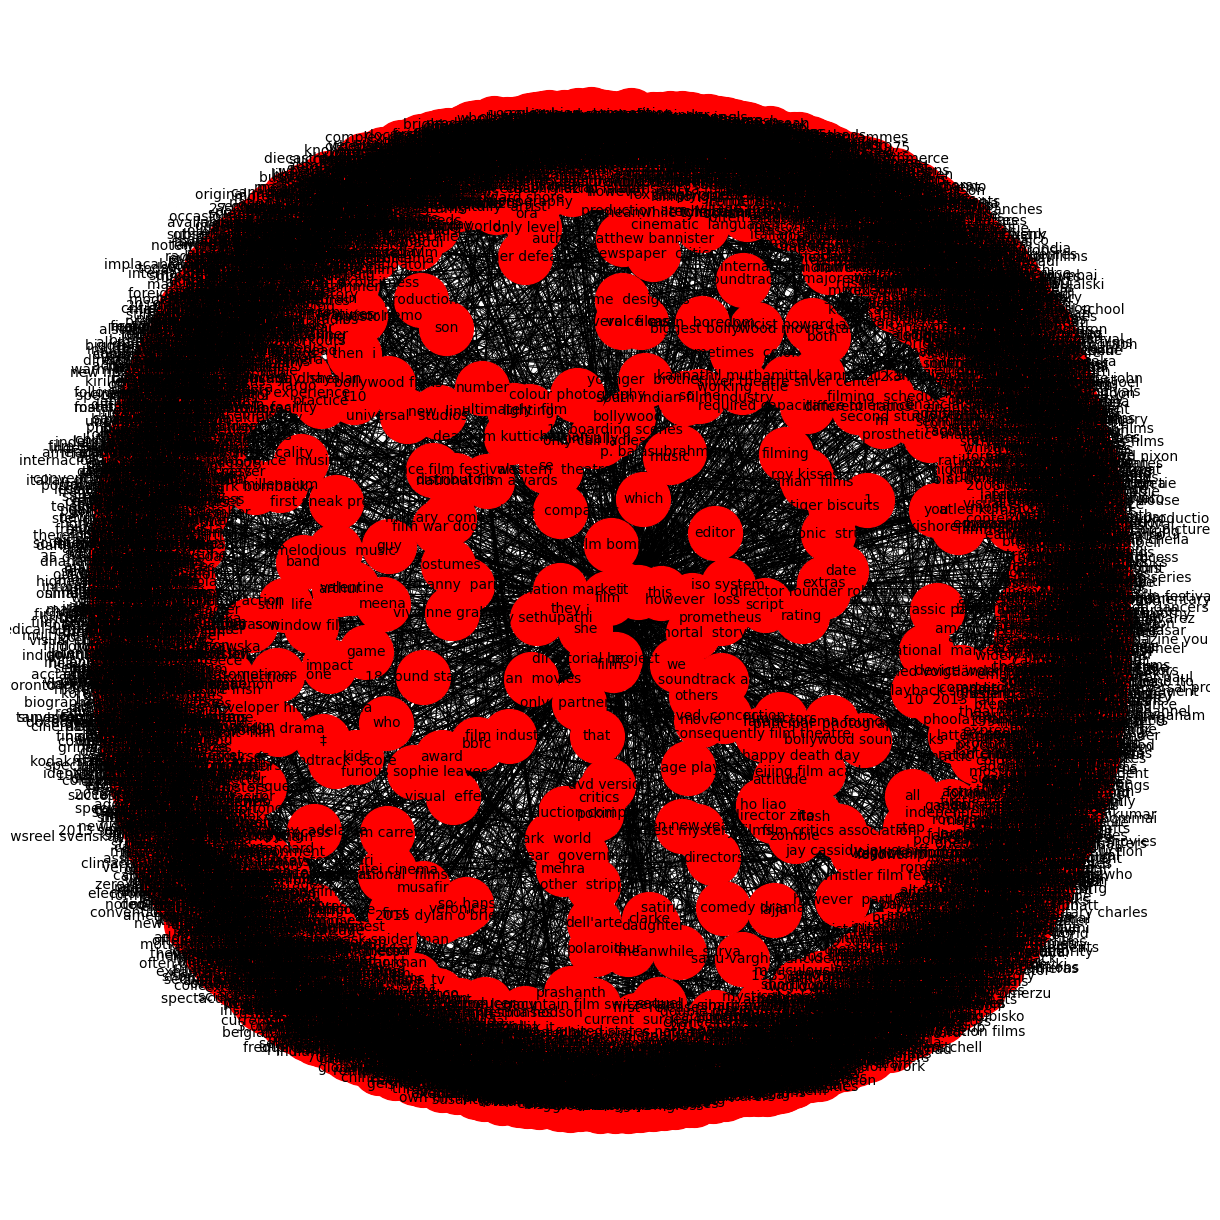

In [ ]:
# Plot the full graph with edge thickness based on weight
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_color='red', edge_color='black', width=[d['weight']*0.5 for (u,v,d) in G.edges(data=True)], font_size=10, node_size=1500)
plt.show()



In [ ]:
# Sample a subset of 500 nodes for a more readable graph
sample_nodes = list(G.nodes)[:200]
G_sample = G.subgraph(sample_nodes)



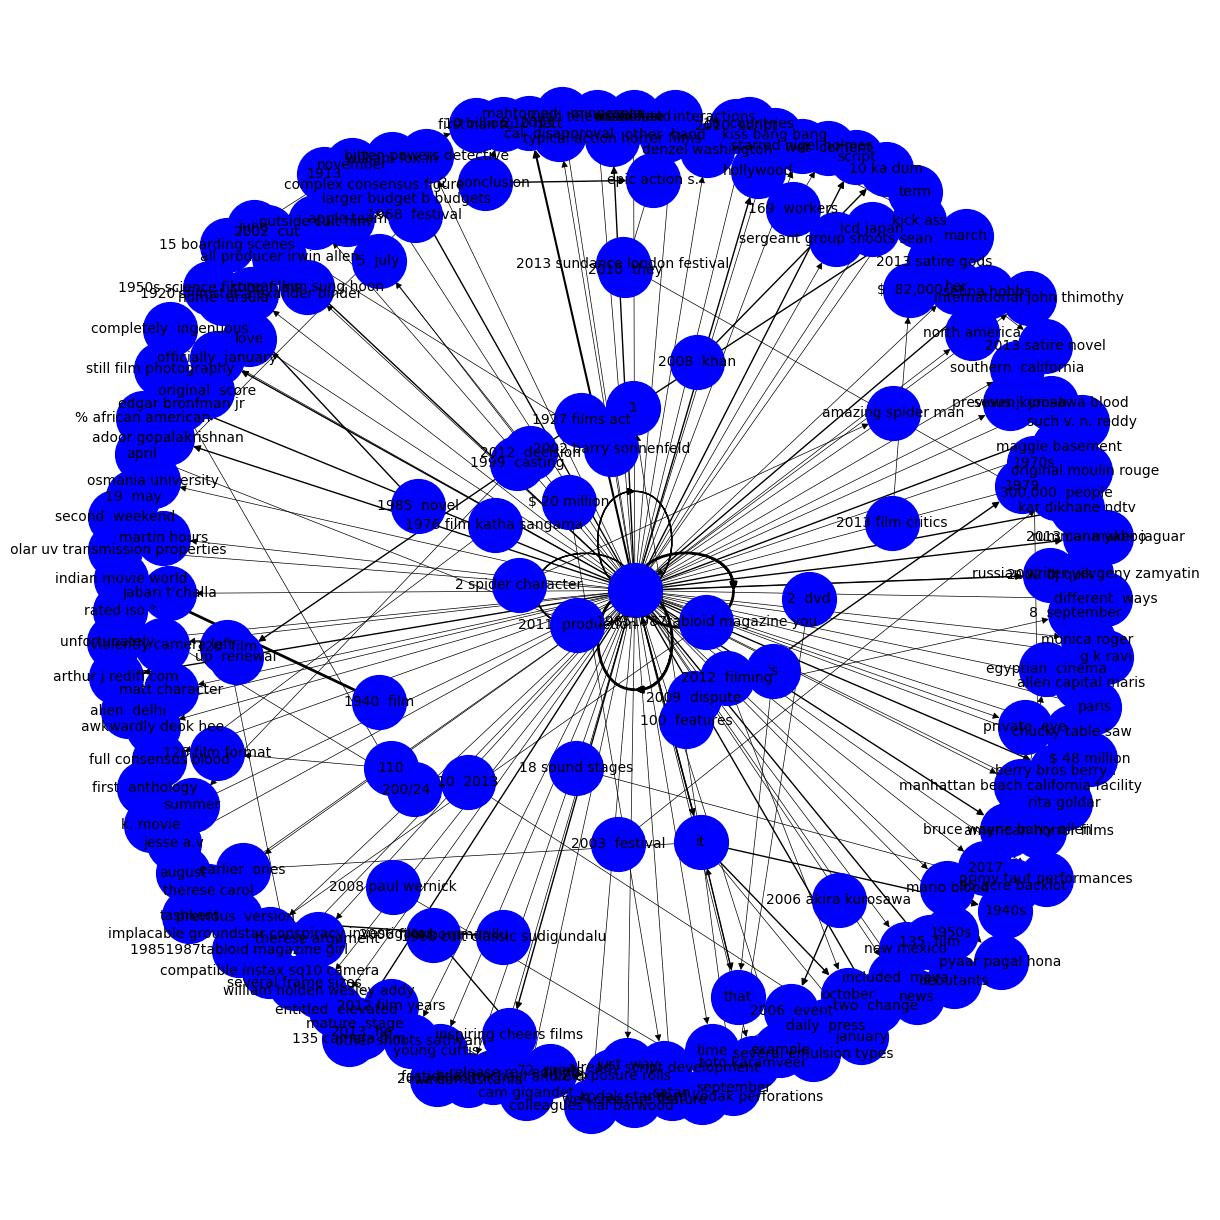

In [ ]:
# Plot the sampled graph
plt.figure(figsize=(12, 12))
pos_sample = nx.spring_layout(G_sample, k=0.5)
nx.draw(G_sample, pos_sample, with_labels=True, node_color='blue', edge_color='black', width=[d['weight']*0.5 for (u,v,d) in G_sample.edges(data=True)], font_size=10, node_size=1500)
plt.show()
